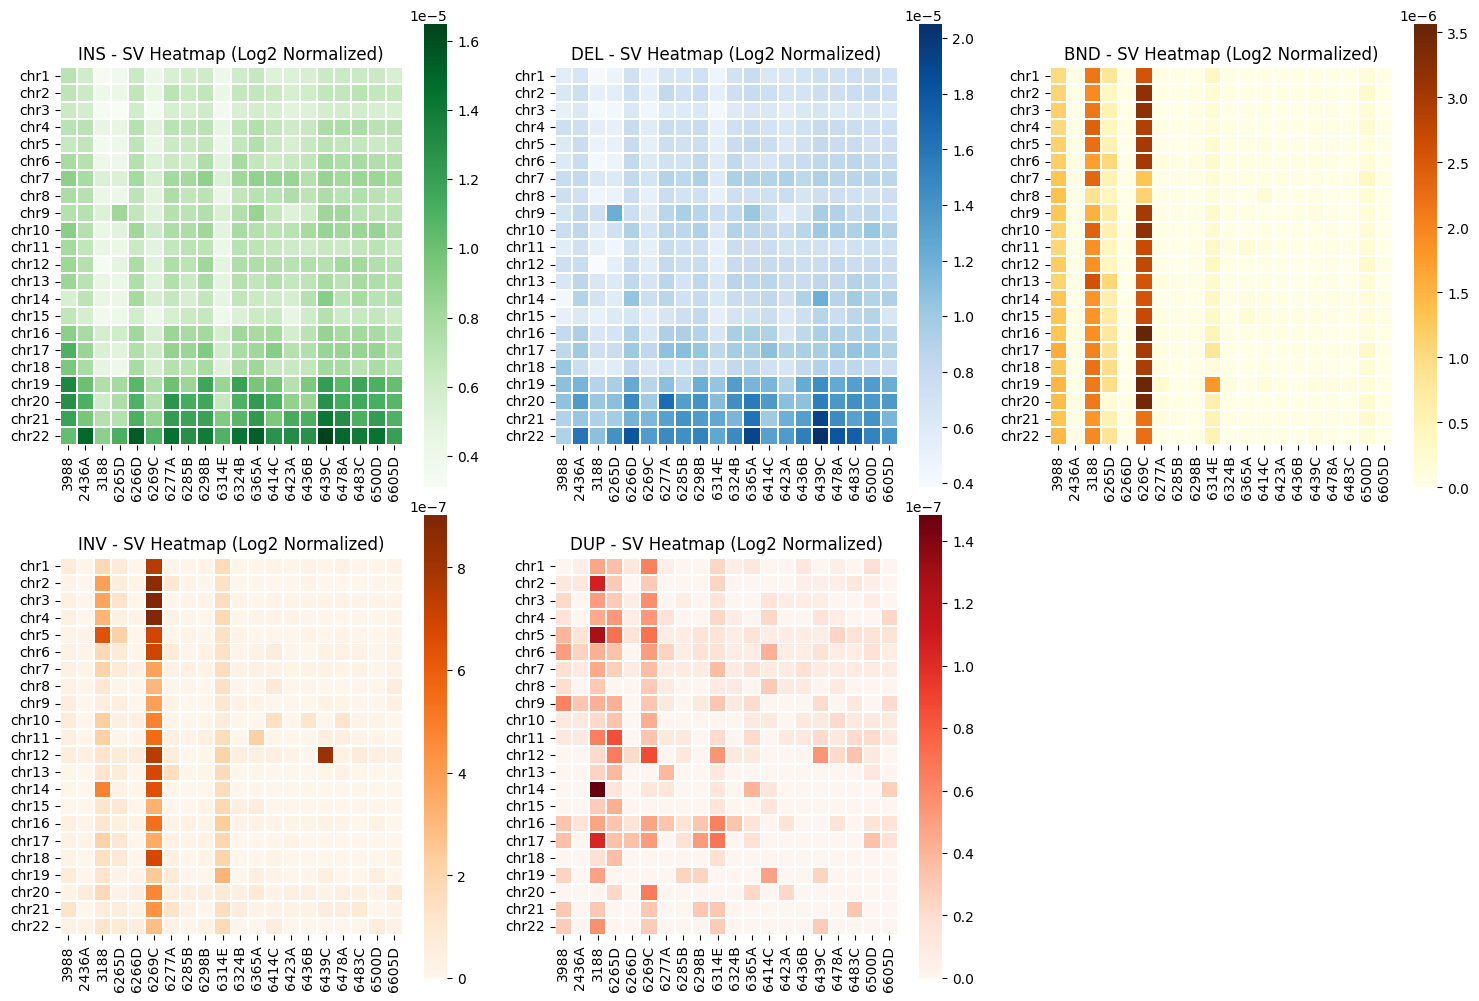

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load the SV data
file_path = '/scratch/mjehangir/manuscript_figures/manuscript_data/SVs_merged_all_samples_SVs_v7.txt'  # Adjust this path
df = pd.read_csv(file_path, sep="\t")

# Filter out unwanted chromosomes (e.g., 'chrM', 'chr', etc.)
df = df[~df['chr'].isin(['chrM', 'chr'])]

# Define T2T chromosome sizes (in base pairs)
chrom_sizes = {
    'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559, 'chr4': 190214555,
    'chr5': 181538259, 'chr6': 170805979, 'chr7': 159345973, 'chr8': 145138636,
    'chr9': 138394717, 'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
    'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189, 'chr16': 90338345,
    'chr17': 83257441, 'chr18': 80373285, 'chr19': 58617616, 'chr20': 64444167,
    'chr21': 46709983, 'chr22': 50818468
}

# Filter out chromosomes not in T2T assembly
df = df[df['chr'].isin(chrom_sizes.keys())]

# Get the unique SV types
sv_types = df['type'].unique()

# Define explicit colormaps for each SV type
sv_colors = {
    'INS': cm.Greens,   # Insertions - Blue
    'DEL': cm.Blues,    # Deletions - Red
    'DUP': cm.Reds,  # Duplications - Green
    'INV': cm.Oranges, # Inversions - Orange
    'BND': cm.YlOrBr   # Breakends - Yellow-Orange-Brown colormap
}

# Increase the figure size for larger heatmaps
fig, axes = plt.subplots(2, int(np.ceil(len(sv_types) / 2)), figsize=(15, 10))
axes = axes.flatten()

# Loop through the SV types
for i, sv_type in enumerate(sv_types):
    ax = axes[i]

    # Filter the dataframe for the current SV type
    df_sv_type = df[df['type'] == sv_type]

    # Create an empty DataFrame to store the count of each SV type per chromosome for all samples
    sv_count_by_chr = pd.DataFrame(columns=df['filename'].unique(), index=chrom_sizes.keys())

    # Fill the dataframe with the counts of the current SV type per chromosome for each sample
    for chrom in chrom_sizes.keys():
        for sample in df['filename'].unique():
            count = len(df_sv_type[(df_sv_type['chr'] == chrom) & (df_sv_type['filename'] == sample)])
            sv_count_by_chr.at[chrom, sample] = count

    # Normalize by chromosome size
    for chrom in sv_count_by_chr.index:
        size = chrom_sizes.get(chrom, 0)  # Get the size for the chromosome
        if size > 0:
            sv_count_by_chr.loc[chrom] = sv_count_by_chr.loc[chrom] / size

    # Convert to float and apply log2 transformation
    sv_count_by_chr = sv_count_by_chr.astype(float)  # Convert to float
    sv_count_by_chr_log = np.log2(sv_count_by_chr + 1)  # Adding 1 to avoid log(0)

    # Create the heatmap for the current SV type
    sns.heatmap(
        sv_count_by_chr_log, annot=False, cmap=sv_colors.get(sv_type, cm.Blues), linewidths=0.7, ax=ax, square=True,
        xticklabels=True, yticklabels=True, cbar=True, cbar_kws={'shrink': 1.2}
    )

    # Set the title for each subplot
    ax.set_title(f'{sv_type} - SV Heatmap (Log2 Normalized)', fontsize=12)

# Remove extra axes if not used
for j in range(len(sv_types), len(axes)):
    fig.delaxes(axes[j])

# Adjust subplot layout to avoid overlap and ensure visibility
plt.tight_layout()

plt.savefig("heatmaps_SVs_type.pdf", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()


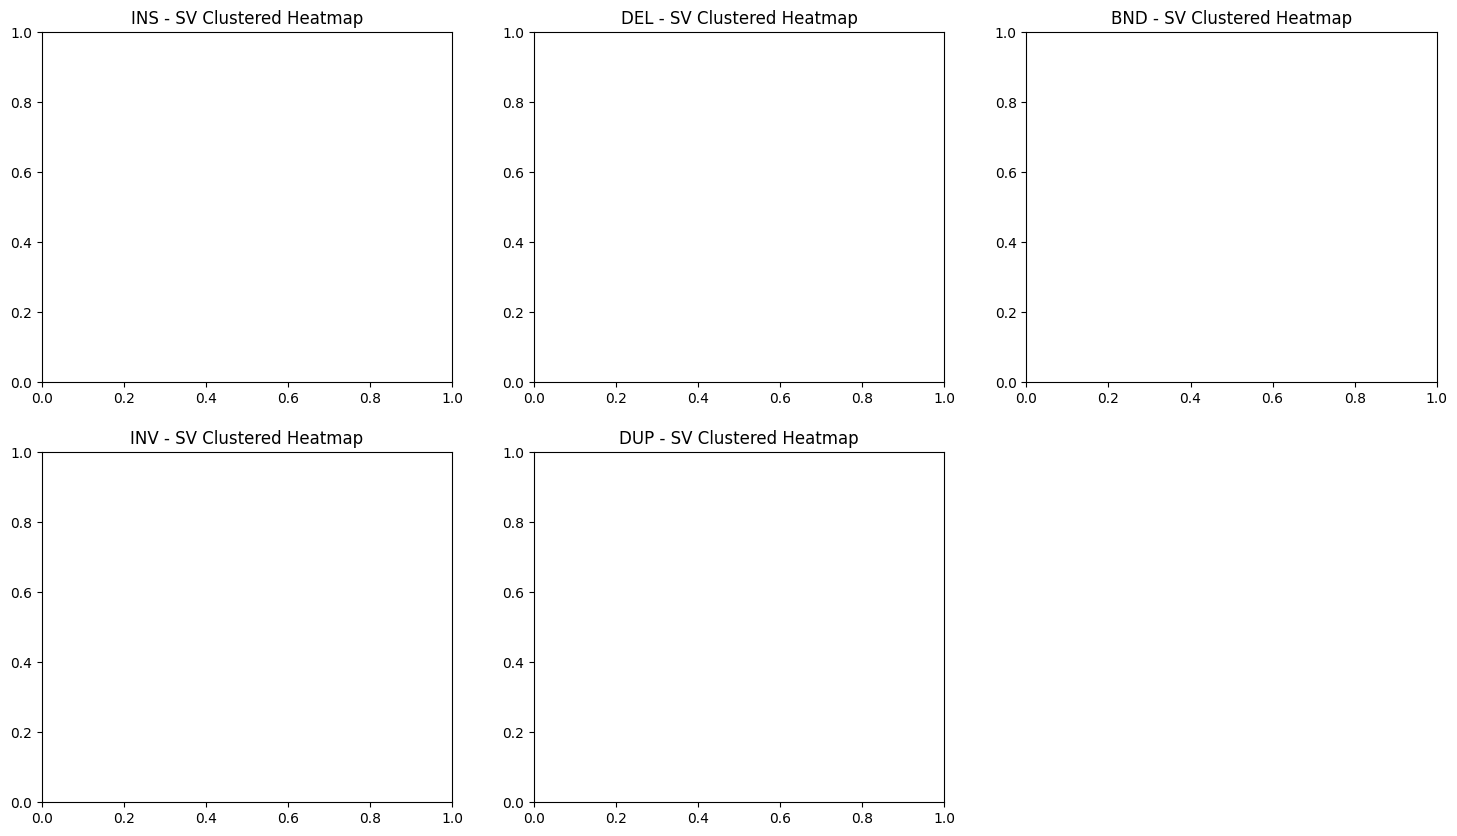

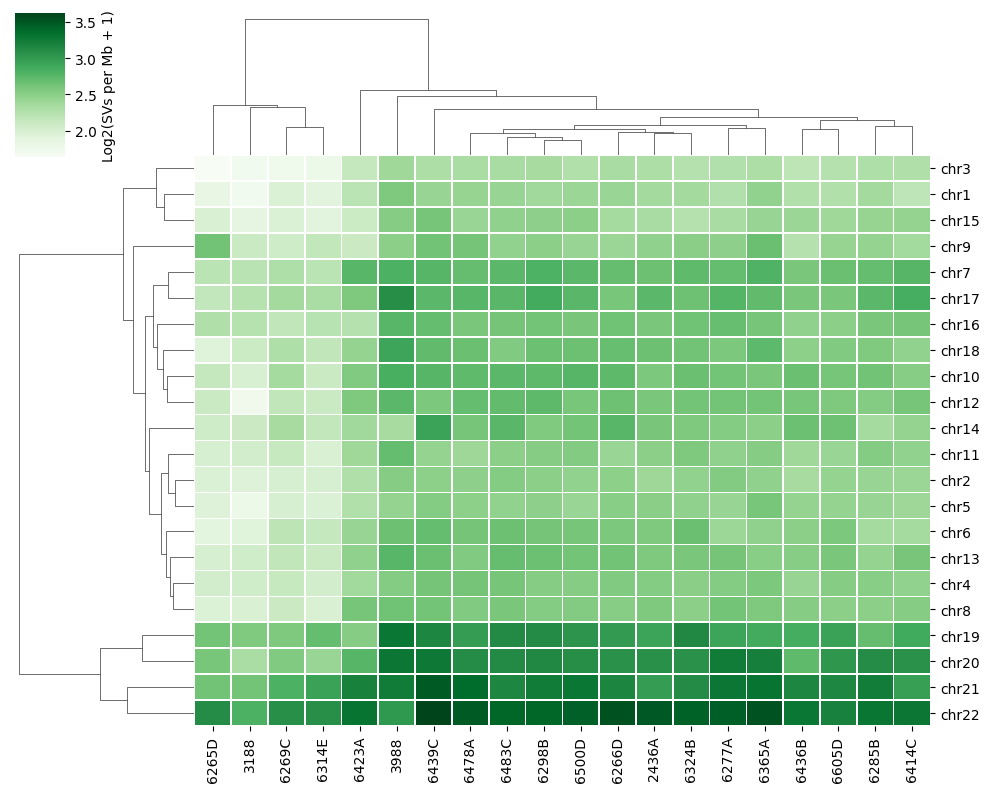

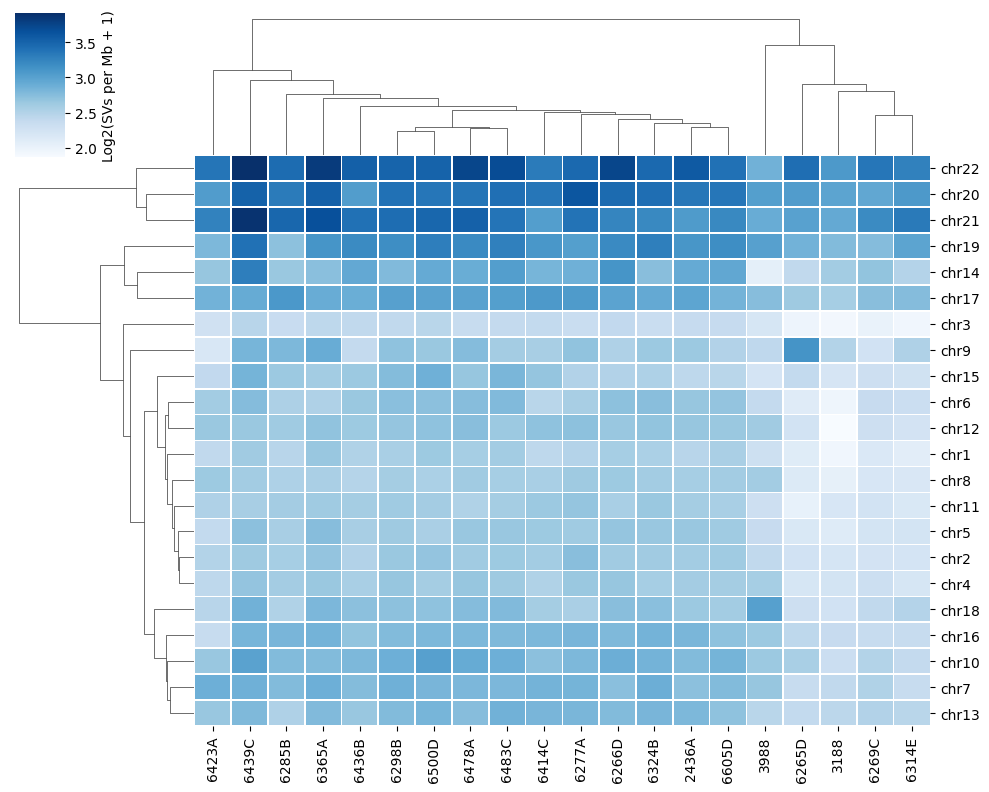

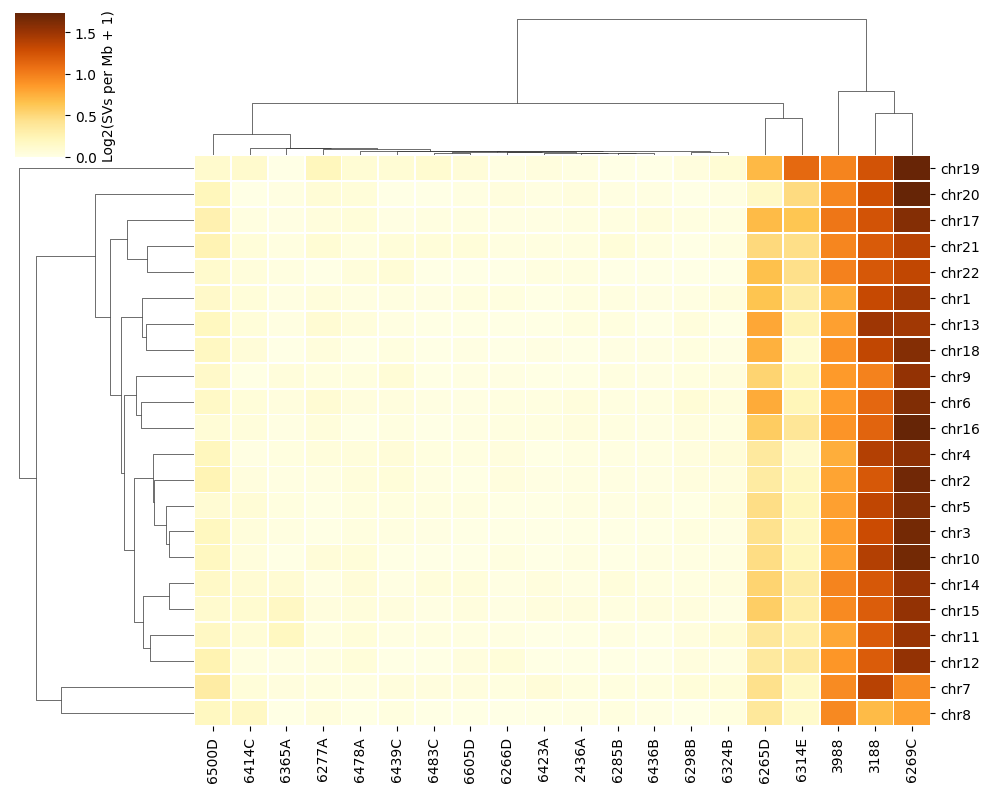

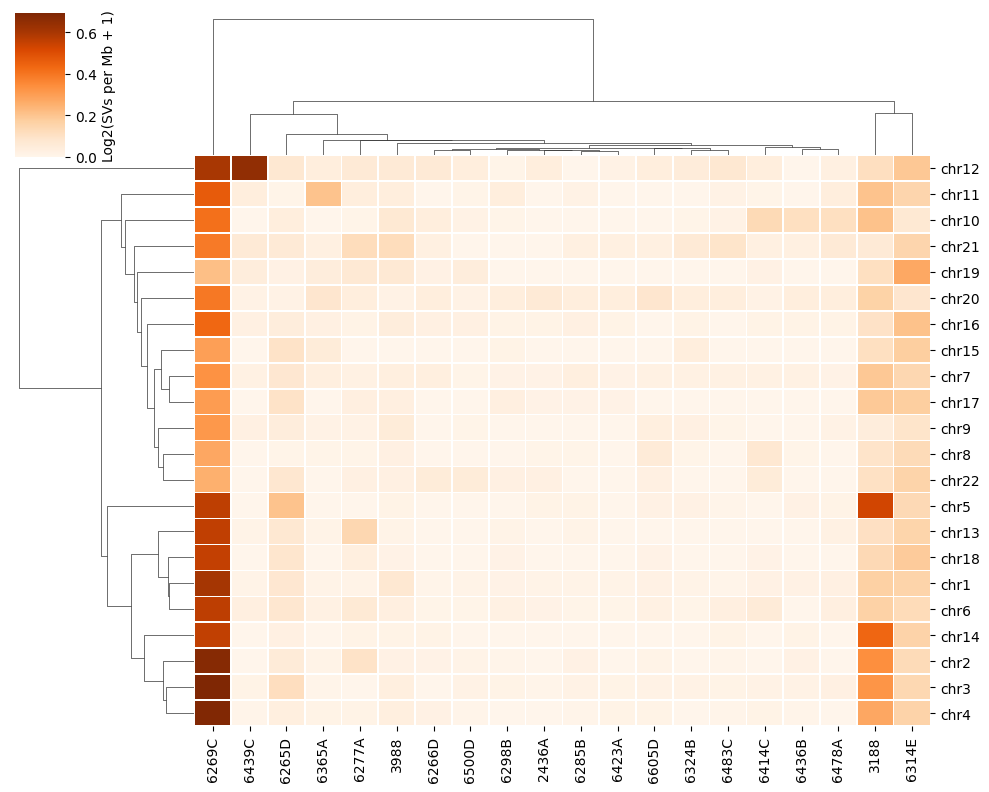

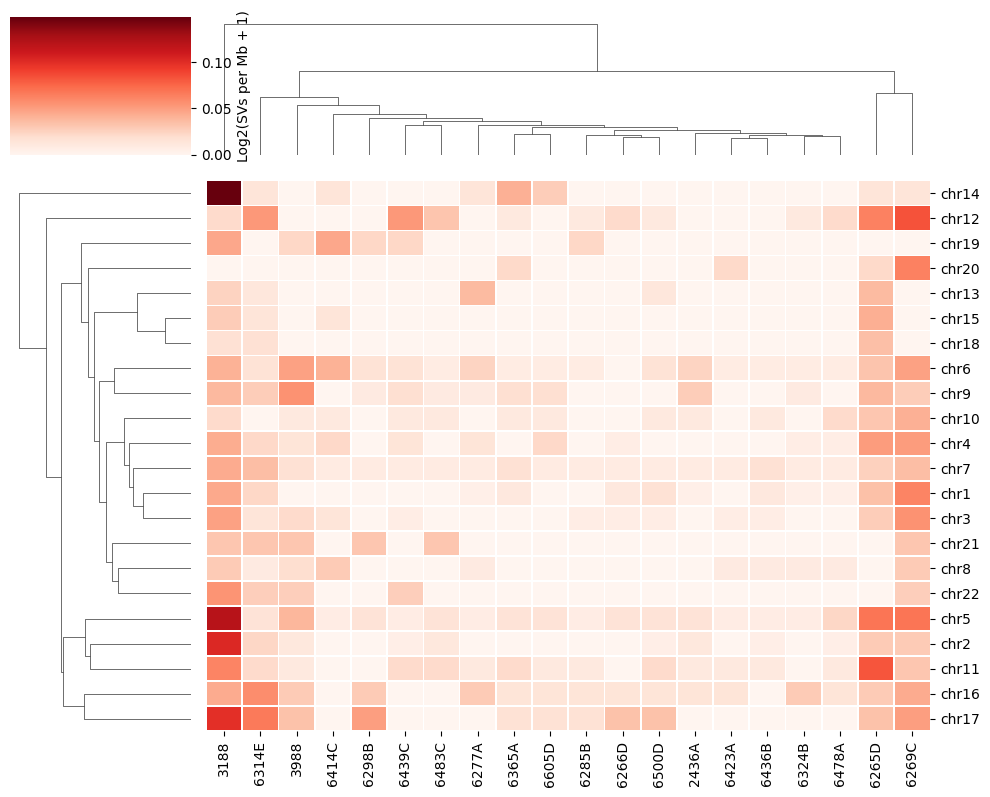

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Load the SV data
file_path = '/scratch/mjehangir/manuscript_figures/manuscript_data/SVs_merged_all_samples_SVs_v7.txt'
df = pd.read_csv(file_path, sep="\t")

# Filter out unwanted chromosomes
df = df[~df['chr'].isin(['chrM', 'chr'])]

# Updated T2T (CHM13v2) chromosome sizes in base pairs
chrom_sizes = {
    'chr1': 248387328, 'chr2': 242696752, 'chr3': 201105948, 'chr4': 193574945,
    'chr5': 182045439, 'chr6': 172126628, 'chr7': 160567428, 'chr8': 146259331,
    'chr9': 150617247, 'chr10': 134758134, 'chr11': 135127769, 'chr12': 133324548,
    'chr13': 113566686, 'chr14': 101161492, 'chr15': 99753195, 'chr16': 96330374,
    'chr17': 84276897, 'chr18': 80542538, 'chr19': 61707364, 'chr20': 66210255,
    'chr21': 45090682, 'chr22': 51324926
}

# Filter data to include only chromosomes in chrom_sizes
df = df[df['chr'].isin(chrom_sizes.keys())]

# Get unique SV types
sv_types = df['type'].unique()

# Define colormaps for SV types
sv_colors = {
    'INS': cm.Greens,
    'DEL': cm.Blues,
    'DUP': cm.Reds,
    'INV': cm.Oranges,
    'BND': cm.YlOrBr
}

# Set up subplots
fig, axes = plt.subplots(2, int(np.ceil(len(sv_types) / 2)), figsize=(18, 10))
axes = axes.flatten()

# Loop through SV types
for i, sv_type in enumerate(sv_types):
    ax = axes[i]

    # Filter SVs of current type
    df_sv_type = df[df['type'] == sv_type]

    # Initialize count DataFrame
    samples = df['filename'].unique()
    sv_count_by_chr = pd.DataFrame(0, index=chrom_sizes.keys(), columns=samples)

    # Count SVs per chromosome per sample
    for chrom in chrom_sizes.keys():
        for sample in samples:
            count = len(df_sv_type[(df_sv_type['chr'] == chrom) & (df_sv_type['filename'] == sample)])
            sv_count_by_chr.at[chrom, sample] = count

    # Normalize by chromosome size in megabases
    for chrom in sv_count_by_chr.index:
        size_mb = chrom_sizes[chrom] / 1e6  # Convert to Mb
        sv_count_by_chr.loc[chrom] = sv_count_by_chr.loc[chrom] / size_mb

    # Log2 transformation
    sv_count_by_chr_log = np.log2(sv_count_by_chr.astype(float) + 1)

    # Clustered heatmap
    sns.clustermap(
        sv_count_by_chr_log,
        cmap=sv_colors.get(sv_type, cm.Blues),
        linewidths=0.5,
        figsize=(10, 8),
        cbar_kws={'label': 'Log2(SVs per Mb + 1)'}
    )

    ax.set_title(f'{sv_type} - SV Clustered Heatmap', fontsize=12)

# Remove unused subplots
for j in range(len(sv_types), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#plt.savefig("clustered_heatmaps_SVs_by_type.pdf", dpi=300, bbox_inches="tight")
plt.show()
